
**Name:Ramya P**

**Reg No:212223230168**

**Ex 01 - Developing a Neural Network Regression Model**

In [4]:
import torch

import torch.nn as nn

import numpy as np 

import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
X = torch.linspace(1,50,50).reshape(-1,1)

In [6]:
X

tensor([[ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.]])

In [7]:
torch.manual_seed(71)
e = torch.randint(-8,9,(50,1),dtype=torch.float)

In [10]:
e

tensor([[ 2.],
        [ 7.],
        [ 2.],
        [ 6.],
        [ 2.],
        [-4.],
        [ 2.],
        [-5.],
        [ 4.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 1.],
        [-8.],
        [ 5.],
        [ 5.],
        [-6.],
        [ 0.],
        [-7.],
        [-8.],
        [-3.],
        [-1.],
        [ 2.],
        [-6.],
        [-3.],
        [ 3.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 1.],
        [ 7.],
        [ 6.],
        [-1.],
        [-6.],
        [-5.],
        [-3.],
        [ 7.],
        [ 0.],
        [ 8.],
        [-1.],
        [-2.],
        [ 2.],
        [-8.],
        [-1.],
        [ 6.],
        [-8.],
        [-3.],
        [-7.],
        [-2.]])

In [8]:
y = 2*X + 1 + e

In [9]:
y

tensor([[ 5.],
        [12.],
        [ 9.],
        [15.],
        [13.],
        [ 9.],
        [17.],
        [12.],
        [23.],
        [22.],
        [25.],
        [28.],
        [28.],
        [21.],
        [36.],
        [38.],
        [29.],
        [37.],
        [32.],
        [33.],
        [40.],
        [44.],
        [49.],
        [43.],
        [48.],
        [56.],
        [57.],
        [60.],
        [63.],
        [66.],
        [64.],
        [72.],
        [73.],
        [68.],
        [65.],
        [68.],
        [72.],
        [84.],
        [79.],
        [89.],
        [82.],
        [83.],
        [89.],
        [81.],
        [90.],
        [99.],
        [87.],
        [94.],
        [92.],
        [99.]])

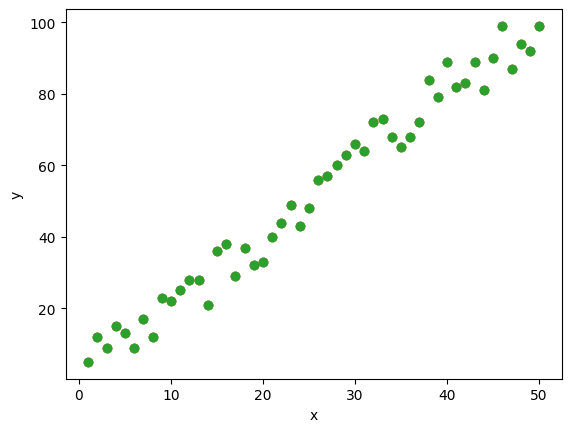

In [11]:
plt.scatter(X, y)
plt.ylabel('y')
plt.xlabel('x')
plt.show()

In [13]:
class Model(nn.Module):
    def __init__(self, in_features, out_features):  
        super().__init__()      
        self.linear = nn.Linear(in_features, out_features)   
        
    def forward(self, x):    
        y_pred = self.linear(x)
        return y_pred

In [14]:
torch.manual_seed(59)
model = Model(1, 1)

In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

In [16]:
epochs = 50 
losses = []

for i in range(epochs):

    i = i +1 

    # Predicting on the Forward Pass   
    y_pred = model.forward(X)
    
    # Calculating our Loss(error) 
    loss = criterion(y_pred, y)

    # Recording that error
    losses.append(loss.item())

    print(f'epoch: {i}  loss: {loss.item()}  weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}') 
    

    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()

    

epoch: 1  loss: 3057.216796875  weight: 0.10597813129425049 bias: 0.9637961387634277
epoch: 2  loss: 1588.5311279296875  weight: 3.334900379180908 bias: 1.0604636669158936
epoch: 3  loss: 830.2999877929688  weight: 1.0148327350616455 bias: 0.9922628402709961
epoch: 4  loss: 438.8524169921875  weight: 2.6817996501922607 bias: 1.0425218343734741
epoch: 5  loss: 236.7615203857422  weight: 1.4840211868286133 bias: 1.0076650381088257
epoch: 6  loss: 132.4291229248047  weight: 2.3446059226989746 bias: 1.0339646339416504
epoch: 7  loss: 78.56572723388672  weight: 1.7262253761291504 bias: 1.0163217782974243
epoch: 8  loss: 50.75775909423828  weight: 2.170504093170166 bias: 1.0302516222000122
epoch: 9  loss: 36.4012336730957  weight: 1.8512457609176636 bias: 1.0214954614639282
epoch: 10  loss: 28.989229202270508  weight: 2.0806007385253906 bias: 1.029038906097412
epoch: 11  loss: 25.162382125854492  weight: 1.9157683849334717 bias: 1.0248701572418213
epoch: 12  loss: 23.186473846435547  weight:

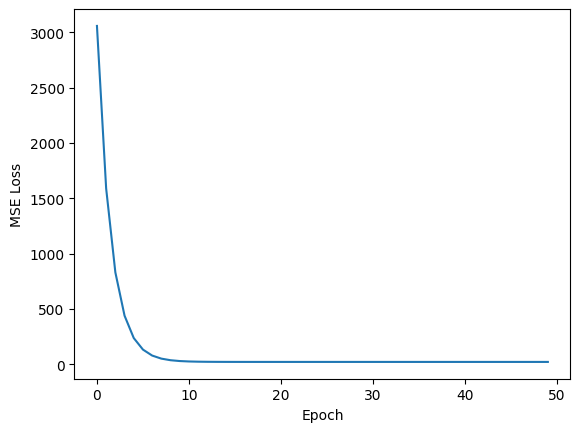

In [17]:
plt.plot(range(epochs), losses)

plt.ylabel('MSE Loss')
plt.xlabel('Epoch');
plt.show()

In [18]:
x = np.linspace(0.0,50.0,50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight * x + current_bias

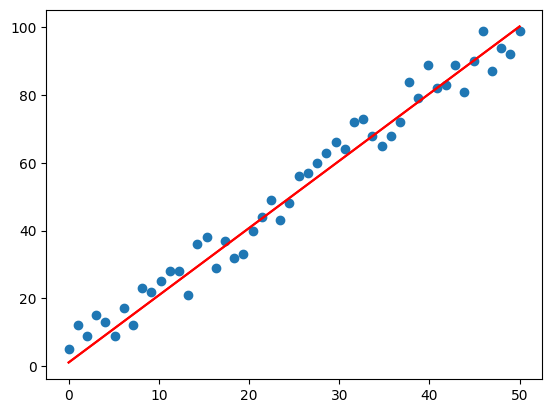

In [20]:
result = plt.plot(x, predicted_y, 'r')

print(result)

plt.scatter(x, y)
plt.plot(x, predicted_y, 'r')
plt.show()